
# Introduction

This exploratory analysis case study is towards Capstone project requirement for [Google Data Analytics Professional Certificate](https://www.coursera.org/professional-certificates/google-data-analytics). It’s originally based on the case study "'Sophisticated, Clear, and Polished’: [Divvy and Data Visualization](https://artscience.blog/home/divvy-dataviz-case-study)" written by Kevin Hartman. The case study involves a fictional bike share company's data of its customer's trip details over a 12 month period (October 2023 - September 2024).

## Scenario

Cyclistic is a **fictional bike-share company** in Chicago, launched in 2016. The company has expanded to a fleet of over 5,800 bikes and nearly 700 docking stations across the city. Cyclistic attracts riders with flexible pricing options, offering single-ride passes, full-day passes, and annual memberships. However, financial insights show that annual members bring in more profit, prompting the marketing team to explore strategies to convert casual riders into annual members.

### Key Stakeholders:

-   Lily Moreno: Director of Marketing, responsible for marketing campaigns and member growth strategies.
-   Cyclistic Marketing Analytics Team: Data analysts who collect and analyze data to guide marketing efforts.
-   Cyclistic Executive Team: Approves or rejects marketing strategies and initiatives based on data-driven insights.

### Business Task

To support Cyclistic’s marketing goal of converting casual riders into annual members, the objective of this analysis is to determine how annual members and casual riders use Cyclistic bikes differently. By identifying key usage patterns and preferences, this analysis will help the marketing team design a data-driven strategy aimed at encouraging casual riders to commit to annual memberships.

#### Key Deliverable:

-   Business Task Statement: A clear and concise definition of the business problem and objectives.
-   Data Source Description: An outline of all data sources used in the analysis, including relevant details and any limitations.
-   Data Cleaning Documentation: A record of the data preparation process, detailing any cleaning, filtering, or transformations applied to ensure data quality.
-   Analysis Summary: A synthesis of findings on the differences in usage between casual riders and annual members.
-   Visualizations and Key Findings: Graphs, charts, and visuals that effectively present the analysis results and highlight key patterns and insights.
-   Top Three Recommendations: Actionable recommendations based on the analysis to help Cyclistic convert casual riders into members.

# Prepare

**Determine the credibility of the data:**

Data has been downloaded from [here](https://divvy-tripdata.s3.amazonaws.com/index.html). All trip data is in comma-delimited (.CSV) format with 13 columns.The time period in consideration is October 2023 - September 2024. Due to the fact that this is a case study using public data, we are going to assume the given dataset is original, comprehensive and it has been properly cited.

This data will allow us to analyze and compare trip duration, bike type usage, trip start and end times, and frequency of rides between casual riders and annual members, supporting the business task of identifying key differences in how these customer segments use Cyclistic bikes.

Note: The datasets have a different name because Cyclistic is a fictional company. The data has been made available by Motivate International Inc. under this [license](https://divvybikes.com/data-license-agreement). The data-privacy issues prohibits from using rider's personally identifiable information.

**Organize the data effectively:**

-   Upload and consolidate the 12-month datasets to create a unified data source.
-   Inspect each dataset for completeness, consistency, and alignment in column names and data types.


In [1]:
#### Installing and loading the required packages
install.packages("tidyverse")
library(tidyverse)
library(lubridate)
library(readr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Warning message:
“unable to access index for repository http://cran.rstudio.com/src/contrib:
  cannot open URL 'http://cran.rstudio.com/src/contrib/PACKAGES'”


Warning message:
“package ‘tidyverse’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
### Load all the datasets
X202310_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202310-divvy-tripdata.csv")
X202311_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202311-divvy-tripdata.csv")
X202312_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202312-divvy-tripdata.csv")
X202401_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202401-divvy-tripdata.csv")
X202402_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202402-divvy-tripdata.csv")
X202403_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202403-divvy-tripdata.csv")
X202404_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202404-divvy-tripdata.csv")
X202405_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202405-divvy-tripdata.csv")
X202406_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202406-divvy-tripdata.csv")
X202407_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202407-divvy-tripdata.csv")
X202408_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202408-divvy-tripdata.csv")
X202409_divvy_tripdata <- read_csv("/kaggle/input/tripdata/Dataset/202409-divvy-tripdata.csv")

Rows: 537113 Columns: 13


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): ride_id, rideable_type, start_station_name, start_station_id, end_...
dbl  (4): start_lat, start_lng, end_lat, end_lng
dttm (2): started_at, ended_at



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 362518 Columns: 13


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): ride_id, rideable_type, start_station_name, start_station_id, end_...
dbl  (4): start_lat, start_lng, end_lat, end_lng
dttm (2): started_at, ended_at


...

── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): ride_id, rideable_type, start_station_name, start_station_id, end_...
dbl  (4): start_lat, start_lng, end_lat, end_lng
dttm (2): started_at, ended_at



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 821276 Columns: 13


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): ride_id, rideable_type, start_station_name, start_station_id, end_...
dbl  (4): start_lat, start_lng, end_lat, end_lng
dttm (2): started_at, ended_at



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
### Merge individual monthly data frames into one large data frame
all_tripdata <- bind_rows(
    X202310_divvy_tripdata,
    X202311_divvy_tripdata,
    X202312_divvy_tripdata,
    X202401_divvy_tripdata,
    X202402_divvy_tripdata,
    X202403_divvy_tripdata,
    X202404_divvy_tripdata,
    X202405_divvy_tripdata,
    X202406_divvy_tripdata,
    X202407_divvy_tripdata,
    X202408_divvy_tripdata,
    X202409_divvy_tripdata
    )

# Process

With all data consolidated, the next step is to clean and prepare it for analysis. This involves addressing any errors, such as removing or imputing NA values, duplicates, and ensuring consistency across the dataset. Additionally, new columns will be created based on calculations from existing columns to provide more meaningful insights. This preparation will make the data easier to work with and support a more thorough analysis, ultimately facilitating deeper conclusions about usage patterns among different rider types.

**Checking the data for errors, NA and duplicates.**

In [4]:
### Checking the data
### Glimpse
glimpse(all_tripdata)

### Summary
summary(all_tripdata)

Rows: 5,854,544
Columns: 13
$ ride_id            <chr> "4449097279F8BBE7", "9CF060543CA7B439", "667F21F4D6…
$ rideable_type      <chr> "classic_bike", "electric_bike", "electric_bike", "…
$ started_at         <dttm> 2023-10-08 10:36:26, 2023-10-11 17:23:59, 2023-10-…
$ ended_at           <dttm> 2023-10-08 10:49:19, 2023-10-11 17:36:08, 2023-10-…
$ start_station_name <chr> "Orleans St & Chestnut St (NEXT Apts)", "Desplaines…
$ start_station_id   <chr> "620", "TA1306000003", "620", "TA1306000003", "TA13…
$ end_station_name   <chr> "Sheffield Ave & Webster Ave", "Sheffield Ave & Web…
$ end_station_id     <chr> "TA1309000033", "TA1309000033", "TA1307000111", "TA…
$ start_lat          <dbl> 41.89820, 41.88864, 41.89807, 41.88872, 41.88872, 4…
$ start_lng          <dbl> -87.63754, -87.64441, -87.63751, -87.64445, -87.644…
$ end_lat            <dbl> 41.92154, 41.92154, 41.88584, 41.88584, 41.88584, 4…
$ end_lng            <dbl> -87.65382, -87.65382, -87.63550, -87.63550, -87.635…
$ member_cas

   ride_id          rideable_type        started_at                    
 Length:5854544     Length:5854544     Min.   :2023-10-01 00:00:05.00  
 Class :character   Class :character   1st Qu.:2024-02-27 05:34:06.75  
 Mode  :character   Mode  :character   Median :2024-06-06 12:55:34.65  
                                       Mean   :2024-05-08 12:56:33.76  
                                       3rd Qu.:2024-08-05 11:12:35.00  
                                       Max.   :2024-09-30 23:54:05.54  
                                                                       
    ended_at                      start_station_name start_station_id  
 Min.   :2023-10-01 00:02:02.00   Length:5854544     Length:5854544    
 1st Qu.:2024-02-27 05:50:02.00   Class :character   Class :character  
 Median :2024-06-06 13:17:11.44   Mode  :character   Mode  :character  
 Mean   :2024-05-08 13:13:52.17                                        
 3rd Qu.:2024-08-05 11:35:24.94                                 

**Clean and add columns**

In [5]:
### Clean the data to be able to properly work with it

# Create separate columns for month, day, year and day of the week from the ride started dates for analysis

all_tripdata_clean <- all_tripdata %>%   
  mutate(date=as.Date(started_at),
         day=day(started_at),
         month=month(started_at, label=TRUE),
         year=year(started_at),
         day_of_week=wday(started_at, label=TRUE))

# Create new column with the duration of the ride

# Ride length in seconds, converted to numeric (dbl) data type in order to perform calculations on the data.
all_tripdata_clean$ride_length_s <- as.numeric(difftime(all_tripdata_clean$ended_at,all_tripdata_clean$started_at))


## Remove the entries where ride_length_s is negative
all_tripdata_clean <- all_tripdata_clean[!all_tripdata_clean$ride_length_s < 0,]

# Drop all NA
all_tripdata_clean <- drop_na(all_tripdata_clean)


# Analyze

With the data now stored and prepared, the next step is to organize and format it for analysis. Aggregating the data will make it both accessible and manageable, allowing for efficient calculations and the identification of trends and relationships. By performing these calculations and exploring key patterns, we can uncover meaningful insights that will support a deeper understanding of rider behavior across different customer segments.

**Conducting Descriptive Analysis**

In [6]:
# Finding the mean, median, min and max of the ride_length: 

mean(all_tripdata_clean$ride_length_s) #straight average (total ride length / rides)
median(all_tripdata_clean$ride_length_s) #midpoint number in the ascending array of ride lengths
max(all_tripdata_clean$ride_length_s) #longest ride
min(all_tripdata_clean$ride_length_s) #shortest ride

[1] 992.3413

[1] 604.098

[1] 90562

[1] 0

**Comparing Member and Casual users**


In [7]:
# Aggregate: Compute Summary Statistics of Data Subsets.
# Splits the data into subsets, computes summary statistics for each, and returns the result in a convenient form.

aggregate(all_tripdata_clean$ride_length_s ~ all_tripdata_clean$member_casual, FUN = mean)
aggregate(all_tripdata_clean$ride_length_s ~ all_tripdata_clean$member_casual, FUN = median)
aggregate(all_tripdata_clean$ride_length_s ~ all_tripdata_clean$member_casual, FUN = max)
aggregate(all_tripdata_clean$ride_length_s ~ all_tripdata_clean$member_casual, FUN = min)

all_tripdata_clean$member_casual,all_tripdata_clean$ride_length_s
<chr>,<dbl>
casual,1437.9193
member,746.2695


all_tripdata_clean$member_casual,all_tripdata_clean$ride_length_s
<chr>,<dbl>
casual,800.000
member,527.111


all_tripdata_clean$member_casual,all_tripdata_clean$ride_length_s
<chr>,<dbl>
casual,90562
member,89859


all_tripdata_clean$member_casual,all_tripdata_clean$ride_length_s
<chr>,<dbl>
casual,0
member,0


**Comparing Member and Casual users on the basis of days of week**

In [8]:
aggregate(all_tripdata_clean$ride_length_s ~ all_tripdata_clean$member_casual + all_tripdata_clean$day_of_week, FUN = mean)
aggregate(all_tripdata_clean$ride_length_s ~ all_tripdata_clean$member_casual + all_tripdata_clean$day_of_week, FUN = median)
aggregate(all_tripdata_clean$ride_length_s ~ all_tripdata_clean$member_casual + all_tripdata_clean$day_of_week, FUN = max)
aggregate(all_tripdata_clean$ride_length_s ~ all_tripdata_clean$member_casual + all_tripdata_clean$day_of_week, FUN = min)

all_tripdata_clean %>% group_by(member_casual,day_of_week) %>% summarise(number_of_rides = n(), average_duration = mean(ride_length_s))

all_tripdata_clean %>% 
  group_by(member_casual, month) %>% 
  summarise(number_of_rides=n(), average_duration=mean(ride_length_s))

all_tripdata_clean$member_casual,all_tripdata_clean$day_of_week,all_tripdata_clean$ride_length_s
<chr>,<ord>,<dbl>
casual,Sun,1656.7197
member,Sun,839.1261
casual,Mon,1389.2329
member,Mon,712.2525
casual,Tue,1245.0609
member,Tue,715.5941
casual,Wed,1289.8878
member,Wed,728.9591
casual,Thu,1247.8082


all_tripdata_clean$member_casual,all_tripdata_clean$day_of_week,all_tripdata_clean$ride_length_s
<chr>,<ord>,<dbl>
casual,Sun,947.000
member,Sun,575.638
casual,Mon,747.000
member,Mon,504.000
casual,Tue,685.598
member,Tue,513.000
casual,Wed,704.747
member,Wed,523.000
casual,Thu,692.000


all_tripdata_clean$member_casual,all_tripdata_clean$day_of_week,all_tripdata_clean$ride_length_s
<chr>,<ord>,<dbl>
casual,Sun,89906.09
member,Sun,89292.28
casual,Mon,89779.86
member,Mon,89666.00
casual,Tue,89852.60
member,Tue,89668.00
casual,Wed,89129.16
member,Wed,89839.00
casual,Thu,89848.93


all_tripdata_clean$member_casual,all_tripdata_clean$day_of_week,all_tripdata_clean$ride_length_s
<chr>,<ord>,<dbl>
casual,Sun,0
member,Sun,0
casual,Mon,0
member,Mon,0
casual,Tue,0
member,Tue,0
casual,Wed,0
member,Wed,0
casual,Thu,0


`summarise()` has grouped output by 'member_casual'. You can override using the
`.groups` argument.


member_casual,day_of_week,number_of_rides,average_duration
<chr>,<ord>,<int>,<dbl>
casual,Sun,264118,1656.7197
casual,Mon,181856,1389.2329
casual,Tue,164419,1245.0609
casual,Wed,188449,1289.8878
casual,Thu,184778,1247.8082
casual,Fri,214749,1384.9470
casual,Sat,305905,1624.8235
member,Sun,302231,839.1261
member,Mon,407050,712.2525


`summarise()` has grouped output by 'member_casual'. You can override using the
`.groups` argument.


member_casual,month,number_of_rides,average_duration
<chr>,<ord>,<int>,<dbl>
casual,Jan,17713,932.1888
casual,Feb,38170,1189.4393
casual,Mar,62818,1321.8468
casual,Apr,93943,1486.3361
casual,May,167550,1616.3274
casual,Jun,208397,1587.0231
casual,Jul,231970,1588.9000
casual,Aug,228518,1488.8746
casual,Sep,216135,1328.7775


**Key Observations**

Weekly Usage Trends:

-   Casual Riders: Casual users show their highest ride frequencies on weekends, particularly on Saturdays (305,905 rides) and Sundays (264,118 rides), accompanied by longer average ride duration (over 1600 seconds). This indicates a preference for leisure activities during the weekend.
-   Member Riders: Members demonstrate peak usage on weekdays, especially on Tuesday (425,817 rides) and Wednesday (452,729 rides), which aligns with commuting patterns. Their average ride duration are shorter than those of casual riders, indicating that their usage is primarily for utilitarian purposes rather than leisure.

Seasonal Patterns:

-   Casual Riders: Casual riders exhibit a notable seasonal trend in ride duration, with average duration increasing from January to April, peaking in May through July, and then tapering off from August to December. This pattern indicates that casual riders engage in longer, recreational rides primarily during the warmer months.
-   Member Riders: In contrast, annual members maintain a more consistent average ride duration throughout the year, with minor increases during the summer months. This suggests that members primarily utilize the bikes for commuting purposes, resulting in shorter, more consistent ride duration.

Comparative Analysis:

-   Casual riders enjoy longer rides, particularly on weekends, while members exhibit higher ride frequencies throughout the week, particularly during weekdays.
-   Casual riders utilize the service mainly for leisurely pursuits, while members rely on it for daily commuting, showcasing a significant difference in usage motivations.

# Share

With insights gained from the above analysis, the next step is to create polished, sophisticated visualizations to effectively communicate findings to the executive team. Selecting the best visualization types will ensure that key trends, such as differences in ride duration and frequency between casual riders and members, are clearly conveyed. Each visualization will be crafted for accessibility, enabling the executive team to easily interpret the insights and assess potential marketing strategies to convert casual riders into annual members.

`summarise()` has grouped output by 'member_casual'. You can override using the
`.groups` argument.


`summarise()` has grouped output by 'member_casual'. You can override using the
`.groups` argument.


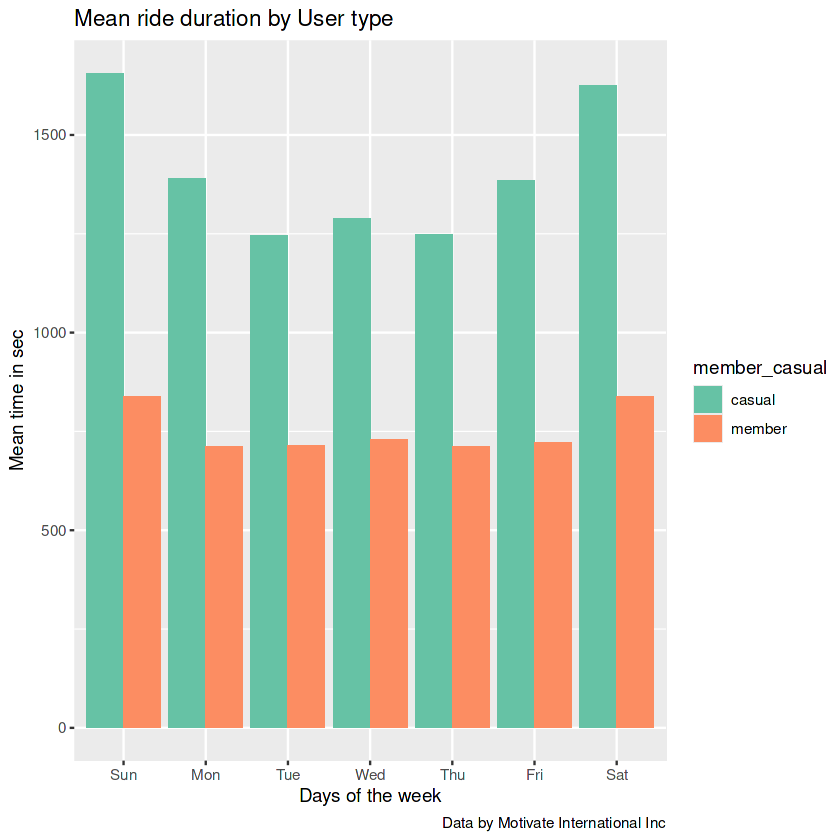

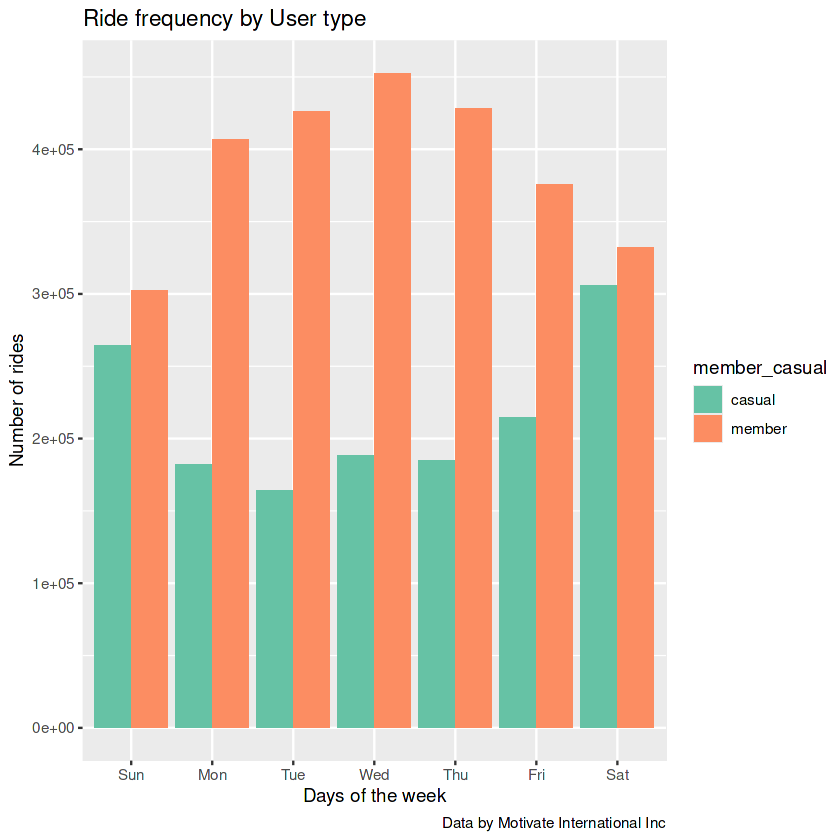

In [9]:
## Mean ride duration by User type over the week
all_tripdata_clean %>% group_by(member_casual,day_of_week) %>% 
  summarise(mean_time = mean(ride_length_s)) %>% 
  ggplot() + geom_col(mapping=aes(x=day_of_week,y=mean_time,fill=member_casual), position = "dodge")+
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Mean ride duration by User type",x="Days of the week",y="Mean time in sec",caption = "Data by Motivate International Inc")

## Mean ride frequency by User type over the week
all_tripdata_clean %>% group_by(member_casual,day_of_week) %>% 
  summarise(number_of_rides = n()) %>% 
  ggplot() + geom_col(mapping=aes(x=day_of_week,y=number_of_rides,fill=member_casual), position = "dodge")+
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Ride frequency by User type",x="Days of the week",y="Number of rides",caption = "Data by Motivate International Inc")

To deepen insights, additional visual analysis will be conducted to further explore usage patterns between casual riders and members. These detailed visuals will offer a clearer view of rider behavior and help highlight specific opportunities for targeted marketing strategies aimed at converting casual riders to annual members.

`summarise()` has grouped output by 'member_casual'. You can override using the
`.groups` argument.


`summarise()` has grouped output by 'member_casual'. You can override using the
`.groups` argument.


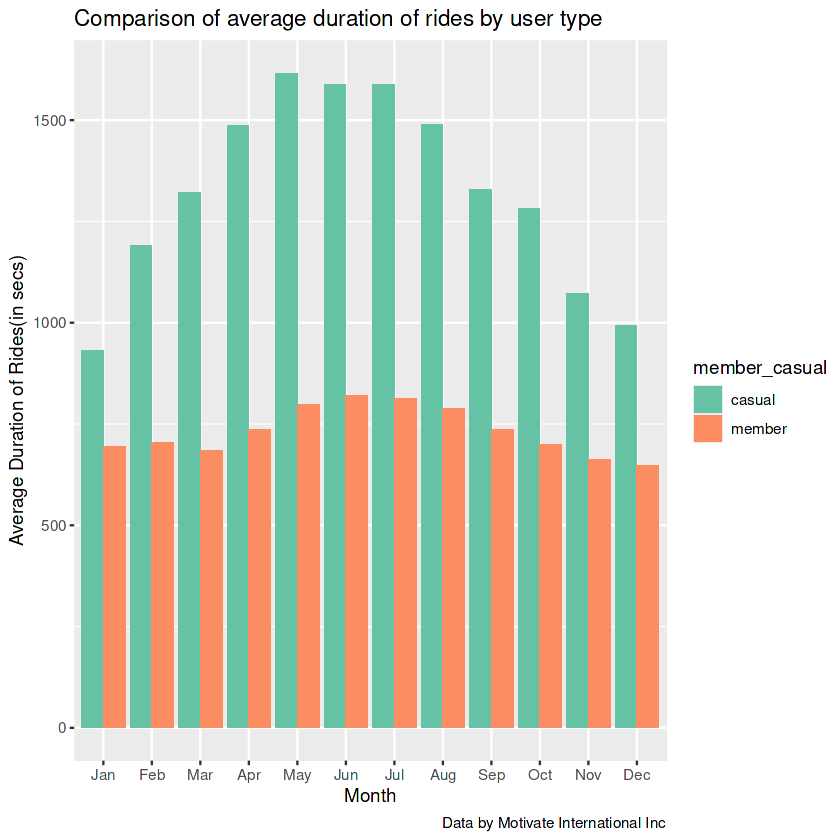

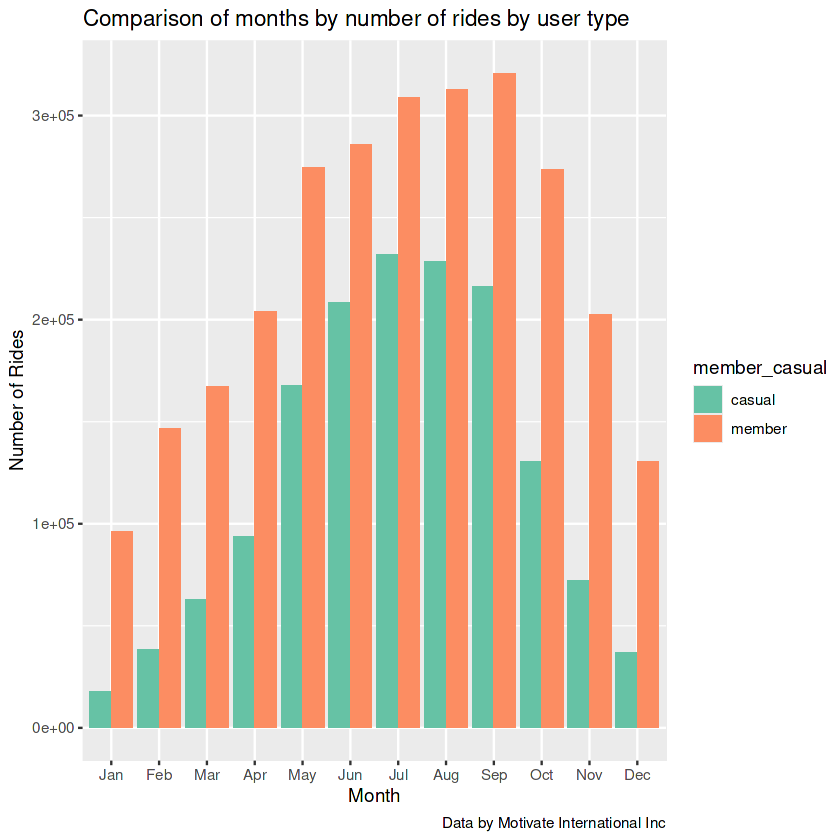

In [10]:
## Analyzing the months by average duration of rides by user type

all_tripdata_clean %>% 
  group_by(member_casual, month) %>% 
  summarise(number_of_rides=n(), average_duration=mean(ride_length_s)) %>%
  ggplot()+ 
  geom_col(mapping=aes(x=month, y=average_duration, fill=member_casual), position="dodge")+
  scale_fill_brewer(palette = "Set2") +
  labs(title= "Comparison of average duration of rides by user type", x = "Month", y = "Average Duration of Rides(in secs)",caption = "Data by Motivate International Inc")

##  Analyzing the months by number of rides by user type

all_tripdata_clean %>% 
  group_by(member_casual, month) %>% 
  summarise(number_of_rides=n(), average_duration=mean(ride_length_s)) %>%
  ggplot()+ 
  geom_col(mapping=aes(x=month, y=number_of_rides, fill=member_casual), position="dodge")+
  scale_fill_brewer(palette = "Set2") +
  labs(title= "Comparison of months by number of rides by user type", x = "Month", y = "Number of Rides",caption = "Data by Motivate International Inc")

`summarise()` has grouped output by 'member_casual'. You can override using the
`.groups` argument.


`summarise()` has grouped output by 'member_casual'. You can override using the
`.groups` argument.


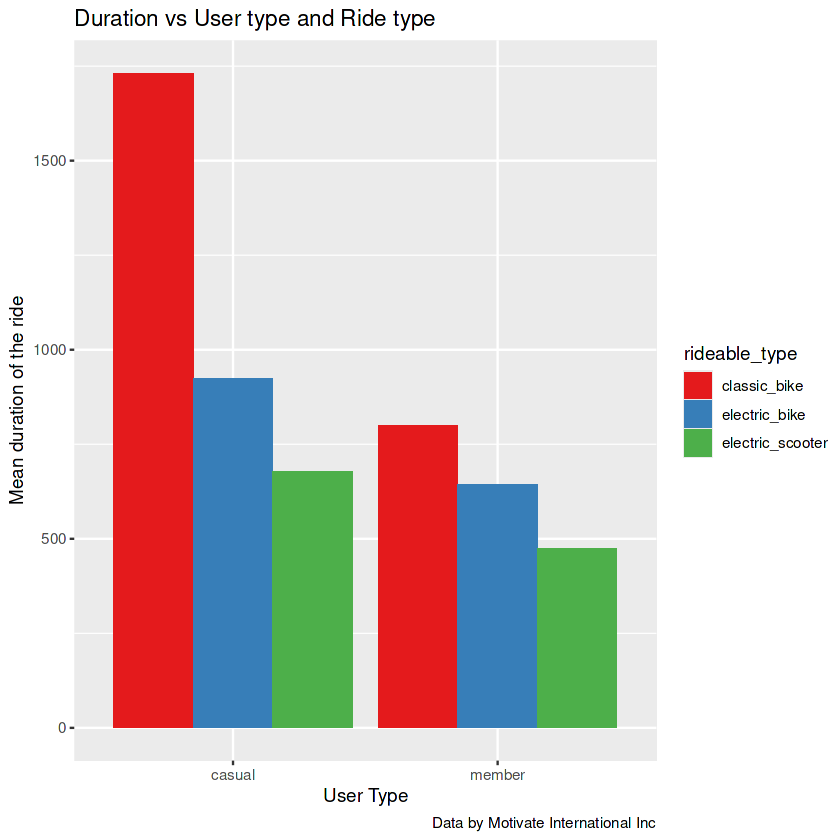

`summarise()` has grouped output by 'rideable_type', 'day_of_week'. You can
override using the `.groups` argument.


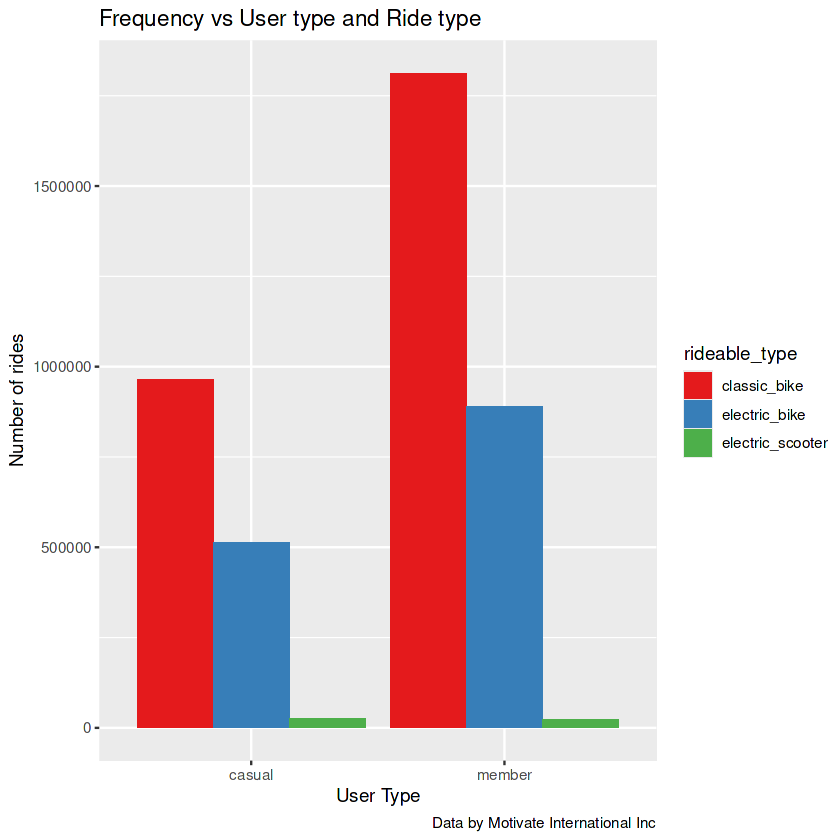

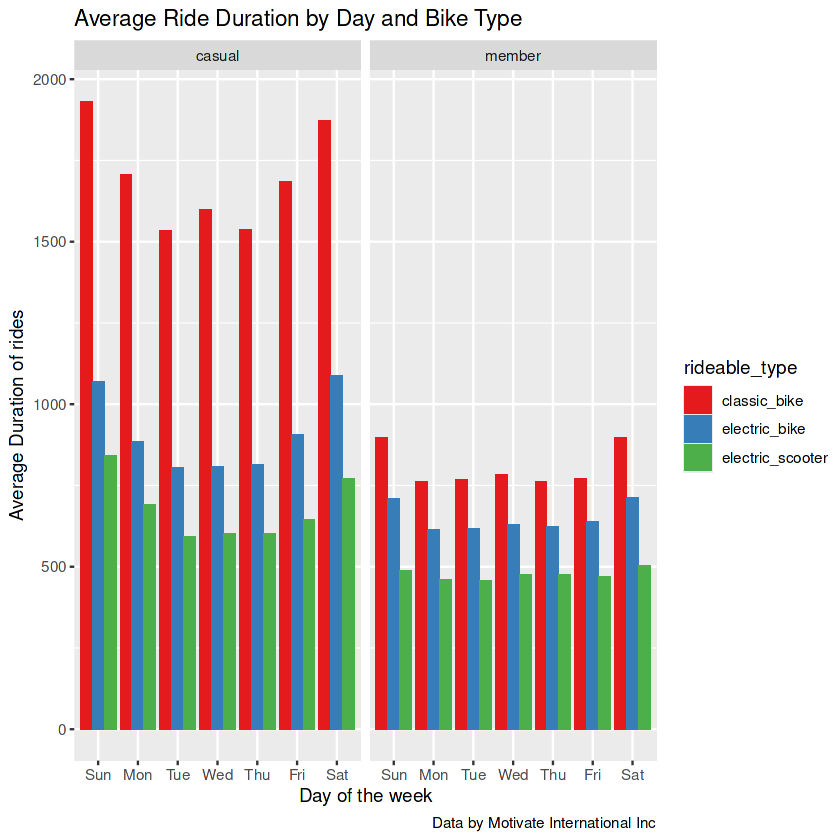

In [11]:
## Duration of rides with various types of rides by users

all_tripdata_clean %>% group_by(member_casual, rideable_type) %>% 
  summarise(average_ride_duration = mean(ride_length_s)) %>% 
  ggplot() +  geom_col(aes(x=member_casual, y=average_ride_duration, fill=rideable_type), position="dodge")+
  scale_fill_brewer(palette = "Set1")+
  labs(title = "Duration vs User type and Ride type",x="User Type",y="Mean duration of the ride",caption = "Data by Motivate International Inc")

## Number of rides with various types of rides by users

all_tripdata_clean %>% group_by(member_casual, rideable_type) %>% 
  summarise(number_of_rides = n()) %>% 
  ggplot() +  geom_col(aes(x=member_casual, y=number_of_rides, fill=rideable_type), position="dodge")+
  scale_fill_brewer(palette = "Set1")+
  labs(title = "Frequency vs User type and Ride type",x="User Type",y="Number of rides",caption = "Data by Motivate International Inc")

## Duration of rides throughout the week by ride type

all_tripdata_clean %>% 
  group_by(rideable_type, day_of_week, member_casual) %>% 
  summarise(average_duration = mean(ride_length_s)) %>%
  ggplot(aes(x = day_of_week, y = average_duration, fill = rideable_type)) +
  geom_col(position = "dodge")+
  facet_wrap(~member_casual)+
  scale_fill_brewer(palette = "Set1") +
  labs(title = "Average Ride Duration by Day and Bike Type",x="Day of the week",y="Average Duration of rides",caption = "Data by Motivate International Inc")

**Key Observations**

-   Ride Duration by User Type: Casual riders tend to have longer average ride durations across all ride types compared to members, with classic bikes having the highest duration for casual riders. Members’ rides are more consistent across types and are generally shorter, possibly indicating utilitarian use like commuting.

-   Ride Frequency by User Type and Vehicle Type: Classic bikes are the most popular ride type among both casual users and members, but the total number of rides is much higher for members. Electric scooters have the lowest usage across both groups, suggesting they may not be the preferred option.

-   Weekly Usage Patterns by Ride Type: Casual riders consistently show longer ride durations on weekends across all vehicle types, indicating likely recreational usage. Members have steadier usage throughout the week, with durations relatively stable, further supporting the idea that they use the service more for routine or commuting purposes.

# Act

Based on the analysis findings, the following actions are recommended to support Cyclistic's goal of converting casual riders into annual members:

-   Targeted Marketing Campaign: Create a campaign aimed at casual riders, emphasizing the benefits of becoming annual members, including potential cost savings and exclusive perks for frequent users.
-   Weekend & Leisure Membership Options: Introduce special membership benefits for weekend and leisure users, such as discounts on classic bikes or weekend passes, to appeal to casual riders who take longer, recreational trips.
-   Leverage Seasonal Insights: Utilize the seasonal patterns observed in ride duration and frequencies to plan promotional events and campaigns. For instance, Cyclistic could organize community events or ride challenges in May to engage casual riders and promote the benefits of membership, particularly during the months when casual riding peaks.
-   Enhance Communication Channels: Utilize digital media effectively to reach casual riders. Implement targeted social media advertisements and email campaigns that emphasize the convenience and cost-effectiveness of annual memberships, particularly during weekends when casual riders are most active.
-   Monitor Conversion Metrics: Track key metrics such as conversion rates, ride frequency, and satisfaction among new members to evaluate the success of these campaigns and offerings.
-   Continuous Data Analysis: Regularly review rider data and update strategies based on patterns in user behavior, allowing for refined, data-driven marketing approaches as trends evolve.

By taking these actions based on the analysis insights, Cyclistic can effectively drive engagement among casual riders, optimize membership conversion strategies, and support overall business growth.

# Conclusion

This actually took longer time than expected, I learned a lot after completing this course and this case study. I would like to extend my heartfelt thanks to all who took the time to read this case study.